# This notebook walks through building an intrusion detection system using the CICIDS2017 dataset #
Including data preprocessing, feature scaling, model training, and performance evaluation across multiple machine learning algorithms.

# 1.Import libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
dataset_file = r"C:\Users\Hp\Downloads\data\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv"
df = pd.read_csv(dataset_file)
print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (286467, 79)
    Destination Port   Flow Duration   Total Fwd Packets  \
0                 22         1266342                  41   
1                 22         1319353                  41   
2                 22             160                   1   
3                 22         1303488                  41   
4              35396              77                   1   

    Total Backward Packets  Total Length of Fwd Packets  \
0                       44                         2664   
1                       44                         2664   
2                        1                            0   
3                       42                         2728   
4                        2                            0   

    Total Length of Bwd Packets   Fwd Packet Length Max  \
0                          6954                     456   
1                          6954                     456   
2                             0                       0   
3                   

In [7]:
print(df.columns.tolist())

[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' ACK Flag Count', ' URG Flag 

# 2.Data cleaning

In [8]:
# Check for any missing values and drop them
total_missing = df.isna().sum().sum()
print(f"Total missing entries found: {total_missing}")
df = df.dropna()

# Identify and remove duplicate rows
initial_rows = df.shape[0]
df = df.drop_duplicates()
removed = initial_rows - df.shape[0]
print(f"Duplicates removed: {removed}. Updated dataset size: {df.shape}")

Total missing entries found: 15
Duplicates removed: 72353. Updated dataset size: (214099, 79)


# 3.Generating Target Labels and Visualizing Their Distribution

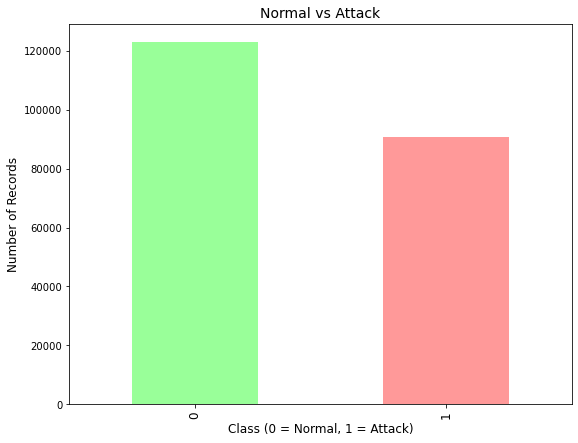

In [9]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# Count target classes
label_counts = df[' Label'].value_counts()

plt.figure(figsize=(9,7))

label_counts.plot.bar(color=['#99FF99', '#FF9999'])  

# Customize x-axis to show 0 and 1
plt.xticks(ticks=[0,1], labels=[0,1], fontsize=12)

# Labels and title
plt.xlabel("Class (0 = Normal, 1 = Attack)", fontsize=12)
plt.ylabel("Number of Records", fontsize=12)
plt.title("Normal vs Attack", fontsize=14)
plt.show()

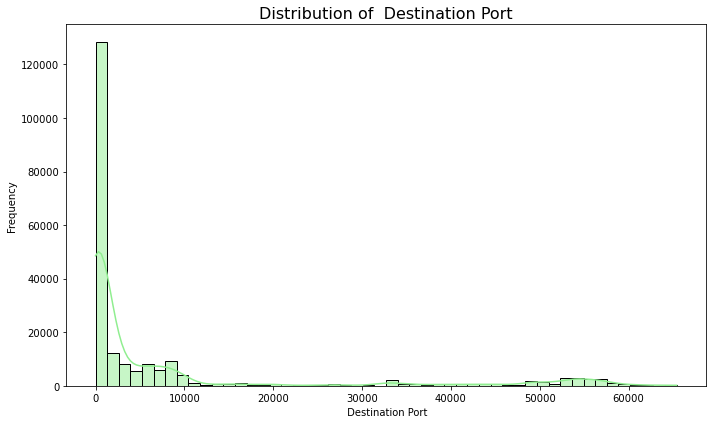

In [10]:
# Select all numeric columns
numeric_cols = df.select_dtypes(include='number').columns
col_to_plot = numeric_cols[0]

plt.figure(figsize=(10,6))
sns.histplot(df[col_to_plot], bins=50, kde=True, color='lightgreen')
plt.title(f"Distribution of {col_to_plot}", fontsize=16)
plt.xlabel(col_to_plot)
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# 4. Label Encoding

In [11]:
cat_features = [col for col in df.select_dtypes(include='object').columns 
                if col not in ['Label', 'attack_binary']]

df = pd.get_dummies(df, columns=cat_features, drop_first=True)

# 5. Scale features

In [12]:

target_col = df.columns[-1]
X = df.drop(columns=[target_col])
y = df[target_col]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 6.split the dataset into training and testing sets

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,        
    y,                
    test_size=0.3,    
    random_state=42,  
    shuffle=True)

# Machine Learning Model Training and Evaluation

## 1. Logistic Regression

In [14]:
# Initialize the logistic regression classifier
logreg = LogisticRegression(
    max_iter=500,          
    class_weight='balanced' 
)

logreg.fit(X_train, y_train)
predictions = logreg.predict(X_test)

acc = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {acc*100:.2f}%\n")
print("Classification Report:\n", classification_report(y_test, predictions))

Model Accuracy: 99.58%

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00     36877
           1       0.99      1.00      1.00     27257

    accuracy                           1.00     64134
   macro avg       1.00      1.00      1.00     64134
weighted avg       1.00      1.00      1.00     64134



## 2.Random Forest

In [15]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100,class_weight='balanced',random_state=42)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_predictions)
print(f"Random Forest Accuracy: {rf_acc*100:.2f}%\n")
print("Classification Report:\n", classification_report(y_test, rf_predictions))

Random Forest Accuracy: 99.99%

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     36877
           1       1.00      1.00      1.00     27257

    accuracy                           1.00     64134
   macro avg       1.00      1.00      1.00     64134
weighted avg       1.00      1.00      1.00     64134



## 3.Decision Tree

In [16]:
tree_clf = DecisionTreeClassifier(class_weight='balanced', random_state=42)
tree_clf.fit(X_train, y_train)

tree_predictions = tree_clf.predict(X_test)

tree_acc = accuracy_score(y_test, tree_predictions)
print(f"Decision Tree Accuracy: {tree_acc*100:.2f}%\n")

print("Classification Report:\n", classification_report(y_test, tree_predictions))

Decision Tree Accuracy: 99.99%

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     36877
           1       1.00      1.00      1.00     27257

    accuracy                           1.00     64134
   macro avg       1.00      1.00      1.00     64134
weighted avg       1.00      1.00      1.00     64134



## Comparison of Model Accuracies

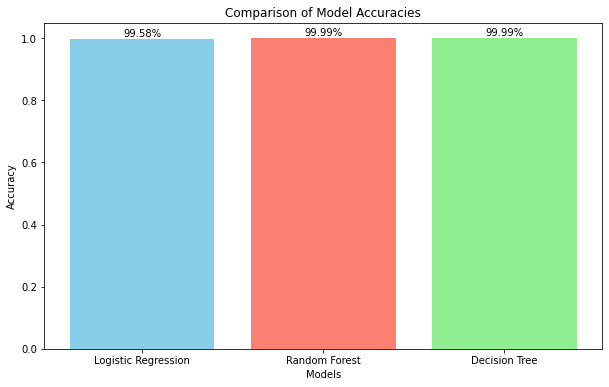

In [17]:
models = ['Logistic Regression', 'Random Forest', 'Decision Tree']
accuracy_scores = [acc, rf_acc, tree_acc]

plt.figure(figsize=(10,6))
bars = plt.bar(models, accuracy_scores, color=['skyblue', 'salmon', 'lightgreen'])
plt.ylim(0, 1.05)
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Comparison of Model Accuracies')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height*100:.2f}%",
        ha='center'
    )

plt.show()

## Visualization of confusion matrix

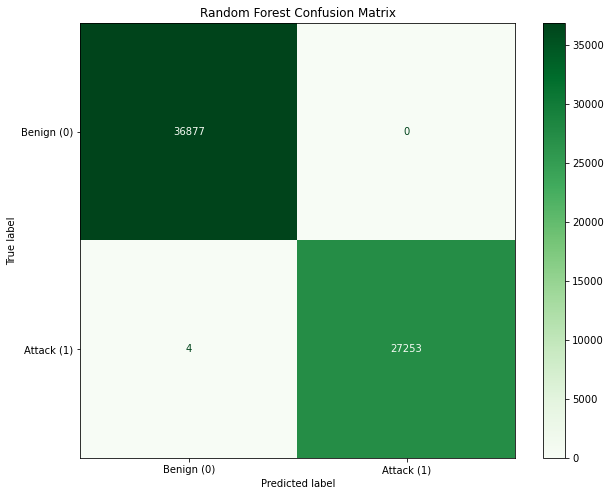

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute confusion matrix for binary classes
cm_matrix = confusion_matrix(y_test, rf_predictions, labels=[0, 1])

# Class labels: 0 = Benign, 1 = Attack
labels = ['Benign (0)', 'Attack (1)']

# Create the display object
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm_matrix, display_labels=labels)

# Plot with customizations
plt.figure(figsize=(10,8))
cm_display.plot(cmap=plt.cm.Greens, ax=plt.gca(), colorbar=True)
plt.title("Random Forest Confusion Matrix")
plt.show()


# ROC

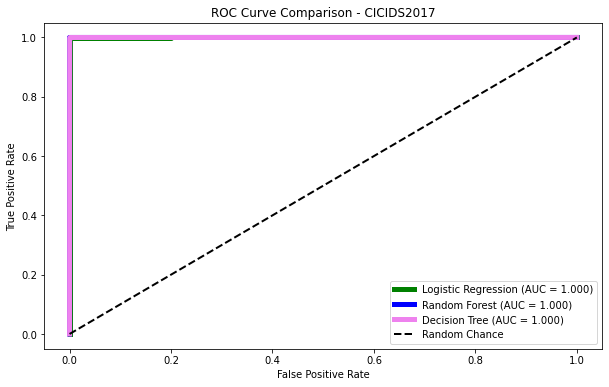

In [14]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
classifier_dict = {
    'Logistic Regression': ('logreg', 'green'),
    'Random Forest': ('rf_model', 'blue'),
    'Decision Tree': ('tree_clf', 'violet')
}

for clf_name, (clf_obj_name, color) in classifier_dict.items():
    clf_obj = globals()[clf_obj_name]
    probs = clf_obj.predict_proba(X_test)[:, 1]
    fpr_vals, tpr_vals, _ = roc_curve(y_test, probs, pos_label=1)
    auc_score = auc(fpr_vals, tpr_vals)
    plt.plot(fpr_vals, tpr_vals, lw=5, color=color, label=f"{clf_name} (AUC = {auc_score:.3f})")

plt.plot([0,1], [0,1], color='black', linestyle='--', lw=2, label="Random Chance")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - CICIDS2017")
plt.legend(loc="lower right")
plt.show()


# Box Plot of Features

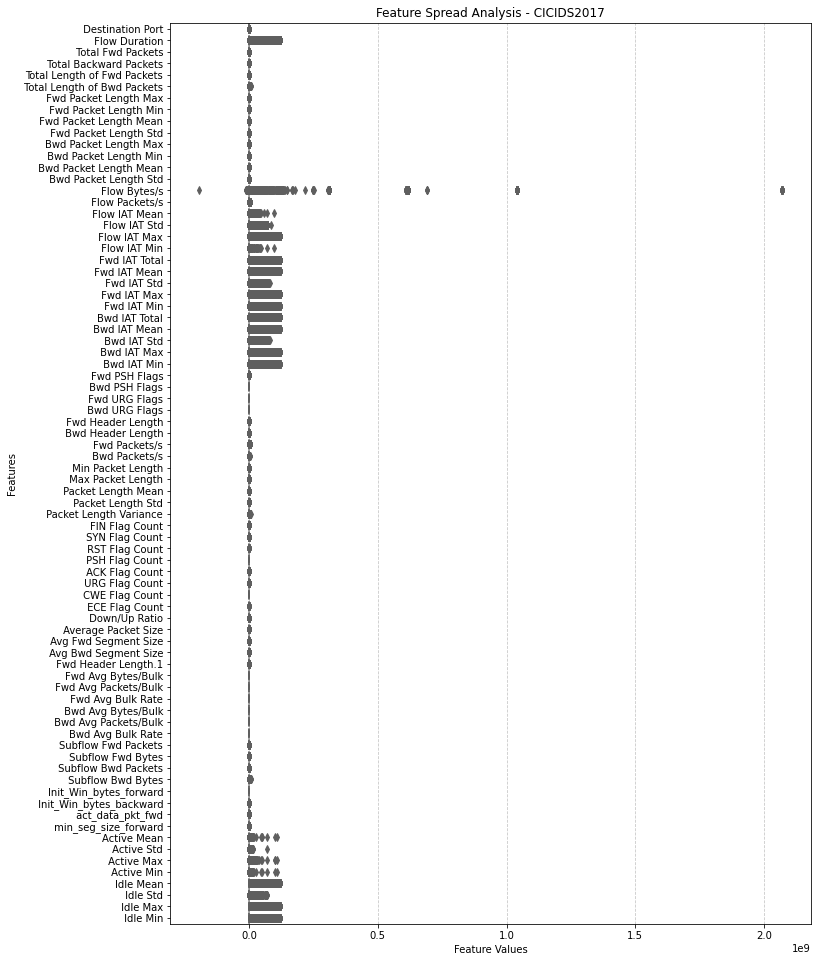

In [15]:
plt.figure(figsize=(12,14))
sns.boxplot(data=X, palette="Set3", orient='h')
plt.title("Feature Spread Analysis - CICIDS2017")
plt.xlabel("Feature Values")
plt.ylabel("Features")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.yticks(fontsize=10) 
plt.tight_layout(pad=3)  

plt.show()


# Correlation heatmap

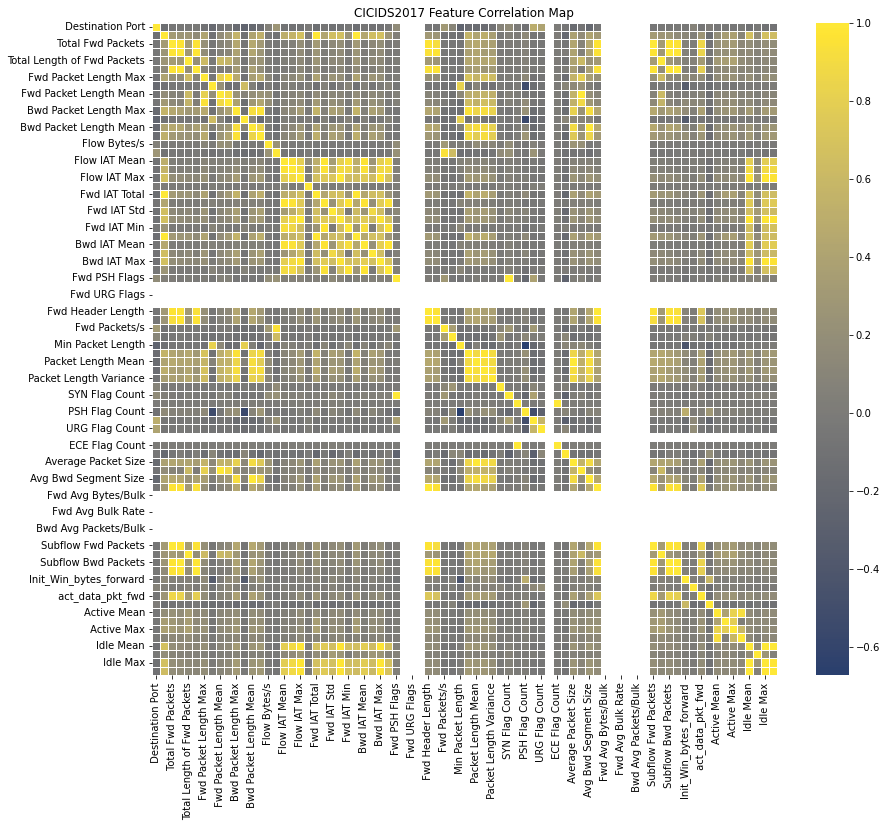

In [16]:
plt.figure(figsize=(14,12))
correlation_matrix = X.corr()
sns.heatmap(correlation_matrix, cmap='cividis', center=0, annot=False, cbar=True, linewidths=0.5)
plt.title("CICIDS2017 Feature Correlation Map")
plt.xticks()
plt.yticks()
plt.show()
